**05 — Sparse-slice MedGS: segmentation-head fine-tuning**

This notebook continues the best local V11 model (`lambda_seg=2`) on the same slices `71..107`.

The 30k V11-B checkpoint is loaded, the shared Gaussian geometry and image head are frozen, and only the existing segmentation head is fine-tuned for 5k additional updates. The segmentation objective keeps the same observed-mask L1 + Dice terms and the same background-aware in-between penalty.

This is a local decision experiment. Full-phase training and the SDF baseline come afterwards.

# 1. Data and configuration

In [1]:
from pathlib import Path

import json
import os
import shutil
import subprocess
import sys

import numpy as np
import pandas as pd
import torch
from PIL import Image
from IPython.display import display

from medgs4d.data import (
    load_phase_volume,
    load_study_manifest,
    window_hu_to_uint8,
)
from medgs4d.mesh_transfer import evaluate_mesh_against_reference
from medgs4d.meshes import (
    TriangleMesh,
    binary_dice,
    binary_iou,
    load_mesh_npz,
    write_ply,
)
from medgs4d.rtstruct import load_geometry
from medgs4d.sparse_joint_visualization import (
    show_sparse_joint_anatomy_3d,
    show_sparse_joint_slice_browser,
)

STACK_ROOT = Path("/home/jovyan/shared/mtm_medgs_stack")
MEDGS_REPO = STACK_ROOT / "repo" / "MedGS"
STUDY_DIR = (
    STACK_ROOT
    / "data"
    / "tcia_4d_lung"
    / "prepared"
    / "patient117_20001024_annotated"
)

PHASE = 0.0
REPRESENTATION = "denoised"

SLICE_STRIDE = 3
POLY_DEGREE = 7
BATCH_SIZE = 3

BASE_ITERATION = 30_000
FINETUNE_ITERATIONS = 5_000
TEST_ITERATIONS = [1_000, 2_000, 3_000, 4_000, 5_000]
TRAIN_HISTORY_INTERVAL = 100

DICE_WEIGHT = 1.0
BG_INTER_WEIGHT = 0.5
ALPHA_MIN = 0.2
ALPHA_MAX = 0.8

MASK_THRESHOLD = 150
MESH_THRESHOLD = 0
RENDER_CHUNKS = 4

TUMOR_START = 86
TUMOR_END = 92
RANGE_START = 71
RANGE_END = 107

FORCE_TRAIN = False

PHASE_TAG = f"{int(PHASE):02d}"
PHASE_DIR = (
    STUDY_DIR
    / "rtstruct_mesh"
    / "tumor_4d"
    / f"phase_{PHASE_TAG}"
)

V11_ROOT = (
    STACK_ROOT
    / "results"
    / "canonical"
    / STUDY_DIR.name
    / (
        f"phase{PHASE_TAG}_joint_local{RANGE_START}_{RANGE_END}_"
        f"stride{SLICE_STRIDE}_poly{POLY_DEGREE}_bginter_v11"
    )
)

V11_B_RUN = V11_ROOT / "B_lambda_seg_2"
V11_B_MODEL = V11_B_RUN / "model"
V11_B_CHECKPOINT = V11_B_MODEL / f"chkpnt{BASE_ITERATION}.pth"

IMG_DATASET = V11_ROOT / "dataset_img"
MASK_DATASET = V11_ROOT / "dataset_mask"

V12_ROOT = (
    STACK_ROOT
    / "results"
    / "canonical"
    / STUDY_DIR.name
    / (
        f"phase{PHASE_TAG}_joint_local{RANGE_START}_{RANGE_END}_"
        f"stride{SLICE_STRIDE}_poly{POLY_DEGREE}_bginter_"
        "v12_seg_finetune"
    )
)

MODEL_DIR = V12_ROOT / "model"
DENSE_MASK_DIR = V12_ROOT / "dense_mask"
EVAL_DIR = V12_ROOT / "evaluation"
TOOLS_DIR = V12_ROOT / "tools"
PATCHED_TRAIN = TOOLS_DIR / "train_seg_finetune_v12.py"

print("Starting checkpoint:", V11_B_CHECKPOINT)
print("V12 output:", V12_ROOT)

Starting checkpoint: /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_local71_107_stride3_poly7_bginter_v11/B_lambda_seg_2/model/chkpnt30000.pth
V12 output: /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_local71_107_stride3_poly7_bginter_v12_seg_finetune


In [2]:
study = load_study_manifest(STUDY_DIR)

ct_hu = np.asarray(
    load_phase_volume(
        study,
        PHASE,
        representation=REPRESENTATION,
        mmap_mode="r",
    )
)

reference_mask = np.load(
    PHASE_DIR / "mask.npy",
    allow_pickle=False,
).astype(bool)

geometry = load_geometry(PHASE_DIR / "geometry.json")
reference_mesh = load_mesh_npz(PHASE_DIR / "mesh_raw.npz")

assert ct_hu.shape == reference_mask.shape == geometry.shape_zyx
assert V11_B_CHECKPOINT.is_file(), V11_B_CHECKPOINT
assert IMG_DATASET.is_dir(), IMG_DATASET
assert MASK_DATASET.is_dir(), MASK_DATASET

evaluation_slices = list(range(RANGE_START, RANGE_END + 1))
observed_slices = list(range(RANGE_START, RANGE_END + 1, SLICE_STRIDE))
observed_set = set(observed_slices)

missing_slices = [
    i for i in evaluation_slices
    if i not in observed_set
]

tumor_slices = list(range(TUMOR_START, TUMOR_END + 1))
tumor_missing_slices = [
    i for i in tumor_slices
    if i not in observed_set
]

observed_empty_slices = [
    i for i in observed_slices
    if not reference_mask[i].any()
]

ground_truth_ct = np.stack(
    [
        window_hu_to_uint8(
            ct_hu[i],
            study.hu_window,
        )
        for i in evaluation_slices
    ]
).astype(np.float32) / 255.0

reference_mask_eval = reference_mask[evaluation_slices]

v11_b_predicted_ct = np.stack(
    [
        np.asarray(
            Image.open(
                V11_B_RUN / "dense_img" / f"{i:04d}.png"
            ).convert("L"),
            dtype=np.float32,
        ) / 255.0
        for i in evaluation_slices
    ]
)

print(
    f"Local range: {RANGE_START}..{RANGE_END}; "
    f"{len(observed_slices)} observed, "
    f"{len(missing_slices)} held out."
)
print("Held-out tumor slices:", tumor_missing_slices)

Local range: 71..107; 13 observed, 24 held out.
Held-out tumor slices: [87, 88, 90, 91]


# 2. Fine-tuning experiment

The starting point is the finished V11-B checkpoint at 30k iterations.

During V12:

- shared geometry stays fixed;
- the image head stays fixed;
- the existing V11-B segmentation head is preserved and optimized;
- no densification, pruning or opacity reset is performed;
- the segmentation loss is

$$
L_{seg}
=
2L_{1,seg}
+
L_{Dice}
+
0.5L_{bg,inter}.
$$

The $L_{sigma}$ term is omitted because `sigma` belongs to the frozen geometry and therefore cannot receive an update.

The background-aware in-between loss is active from the first fine-tuning update, because this is a continuation of the already trained 30k model rather than a new warm-up.

# 3. Private MedGS fine-tuning script

In [3]:
def build_v12_train_script() -> Path:
    """Create a private MedGS script for segmentation-head-only fine-tuning."""

    TOOLS_DIR.mkdir(parents=True, exist_ok=True)

    source = (MEDGS_REPO / "train.py").read_text(
        encoding="utf-8"
    )

    if "import csv\n" not in source:
        source = source.replace(
            "import os\n",
            "import os\nimport csv\n",
            1,
        )

    insert_at = source.index("def training_joint(")

    function_source = f"""
def training_binary_segmentation_v12(
    gs_type,
    dataset,
    opt,
    pipe,
    testing_iterations,
    saving_iterations,
    checkpoint_iterations,
    checkpoint,
    debug_from,
    save_xyz,
    use_dff,
    seg_head_only=False,
):
    if not seg_head_only:
        raise ValueError("V12 requires --seg_head_only")
    if checkpoint is None:
        raise ValueError("V12 requires --start_checkpoint")

    time_start = time.process_time()
    init_time = time.time()

    tb_writer = prepare_output_and_logger(dataset)

    frames = len(os.listdir(f"{{dataset.source_path}}/original"))
    print("frames", frames)

    gaussians = gaussianModel[gs_type](
        dataset.sh_degree,
        dataset.poly_degree,
        frames,
        use_dff=use_dff,
    )
    scene = Scene(dataset, gaussians, shuffle=False)

    model_params, checkpoint_iteration = torch.load(
        checkpoint,
        map_location="cuda",
    )

    if not isinstance(model_params, dict):
        raise RuntimeError("Expected a dictionary checkpoint from V11-B")

    opacity_seg = model_params.get("_opacity_seg", None)
    if (
        opacity_seg is None
        or not hasattr(opacity_seg, "numel")
        or opacity_seg.numel() == 0
    ):
        raise RuntimeError(
            "The starting checkpoint does not contain the trained segmentation head"
        )

    gaussians.restore(
        model_params,
        training_args=None,
        load_optimizer=False,
    )

    gaussians.freeze_geometry_and_img_head()

    seg_params = gaussians.seg_head_parameters()
    if not seg_params:
        raise RuntimeError("No segmentation-head parameters found")

    gaussians.optimizer = torch.optim.Adam(
        [
            {{
                "params": seg_params,
                "lr": opt.feature_lr,
                "name": "seg_head",
            }}
        ],
        lr=0.0,
        eps=1e-15,
    )

    print(
        "V12 fine-tuning: preserving V11-B segmentation head; "
        "geometry and image head are frozen."
    )
    print("Starting checkpoint iteration:", checkpoint_iteration)
    print("Segmentation-head learning rate:", opt.feature_lr)

    bg_color = [1, 1, 1] if dataset.white_background else [0, 0, 0]
    background = torch.tensor(
        bg_color,
        dtype=torch.float32,
        device="cuda",
    )
    bg = (
        torch.rand((3), device="cuda")
        if opt.random_background
        else background
    )

    viewpoint_cameras = scene.getTrainCameras()
    num_frames = len(viewpoint_cameras)

    gts = [
        cam.get_image(bg, opt.random_background).cuda()
        for cam in viewpoint_cameras
    ]

    prev_next_overlap = 2 if dataset.camera == "mirror" else 1
    print("prev_next_overlap", prev_next_overlap)

    history_dir = os.path.join(scene.model_path, "history")
    os.makedirs(history_dir, exist_ok=True)
    train_history_path = os.path.join(
        history_dir,
        "seg_finetune_history.csv",
    )

    with open(train_history_path, "w", newline="") as fp:
        writer = csv.writer(fp)
        writer.writerow([
            "iteration",
            "effective_iteration",
            "seg_l1",
            "dice_loss",
            "bg_inter",
            "seg_total",
        ])

    iter_start = torch.cuda.Event(enable_timing=True)
    iter_end = torch.cuda.Event(enable_timing=True)

    ema_loss = 0.0
    progress_bar = tqdm(
        range(0, opt.iterations),
        desc="V12 segmentation fine-tuning",
    )

    for iteration in range(1, opt.iterations + 1):
        effective_iteration = int(checkpoint_iteration) + iteration
        iter_start.record()

        idx = randint(0, num_frames - 1)

        camera_prev = (
            viewpoint_cameras[idx - prev_next_overlap]
            if idx - prev_next_overlap >= 0
            else None
        )
        camera = viewpoint_cameras[idx]
        camera_next = (
            viewpoint_cameras[idx + prev_next_overlap]
            if idx + prev_next_overlap <= num_frames - 1
            else None
        )

        cameras = {{
            "camera_prev": camera_prev,
            "camera": camera,
            "camera_next": camera_next,
        }}

        outputs = {{}}

        for name, cam in cameras.items():
            if cam is None:
                continue

            rpkg = render(
                cam,
                gaussians,
                pipe,
                bg,
                train=True,
                iter=effective_iteration,
                seg=True,
                head="seg",
            )

            if name == "camera_prev":
                rpkg["gt"] = gts[idx - prev_next_overlap]
            elif name == "camera":
                rpkg["gt"] = gts[idx]
            else:
                rpkg["gt"] = gts[idx + prev_next_overlap]

            outputs[name] = rpkg

        data = {{}}

        for key in outputs["camera"].keys():
            if key == "viewspace_points":
                data[key] = [o[key] for o in outputs.values()]
            elif key in ["visibility_filter", "radii"]:
                data[key] = [o[key] for o in outputs.values()]
            elif key in ["render", "gt", "mask"]:
                data[key] = torch.stack(
                    [o[key] for o in outputs.values()],
                    dim=0,
                )

        Ll1_seg = l1_loss(
            data["render"],
            data["gt"],
        )

        seg_pred = data["render"].clamp(0.0, 1.0)
        seg_gt = data["gt"].clamp(0.0, 1.0)

        dice_dims = tuple(range(1, seg_pred.ndim))
        dice_intersection = (
            seg_pred * seg_gt
        ).sum(dim=dice_dims)
        dice_denominator = (
            seg_pred.sum(dim=dice_dims)
            + seg_gt.sum(dim=dice_dims)
        )
        dice_loss_seg = 1.0 - (
            (2.0 * dice_intersection + 1e-6)
            / (dice_denominator + 1e-6)
        ).mean()

        bg_terms = []

        intervals = []

        if camera_prev is not None:
            intervals.append((
                camera_prev,
                gts[idx - prev_next_overlap],
                gts[idx],
            ))

        if camera_next is not None:
            intervals.append((
                camera,
                gts[idx],
                gts[idx + prev_next_overlap],
            ))

        for inter_cam, A_seg, B_seg in intervals:
            alpha_seg = np.random.uniform(
                {ALPHA_MIN},
                {ALPHA_MAX},
            )

            A_empty = bool(
                (A_seg > 0.5).sum().item() == 0
            )
            B_empty = bool(
                (B_seg > 0.5).sum().item() == 0
            )

            if A_empty and B_empty:
                bg_weight = 1.0
            elif A_empty and not B_empty:
                bg_weight = (1.0 - alpha_seg) ** 2
            elif not A_empty and B_empty:
                bg_weight = alpha_seg ** 2
            else:
                bg_weight = 0.0

            if bg_weight > 0.0:
                rpkg_inter = render(
                    inter_cam,
                    gaussians,
                    pipe,
                    bg,
                    train=True,
                    iter=effective_iteration,
                    seg=True,
                    head="seg",
                    alpha=alpha_seg,
                )

                inter_seg = rpkg_inter[
                    "render"
                ].clamp(0.0, 1.0)

                bg_terms.append(
                    float(bg_weight)
                    * inter_seg.abs().mean()
                )

        if bg_terms:
            L_bg_inter = torch.stack(bg_terms).mean()
        else:
            L_bg_inter = torch.tensor(
                0.0,
                device=data["render"].device,
                dtype=data["render"].dtype,
            )

        loss = (
            2.0 * Ll1_seg
            + {DICE_WEIGHT} * dice_loss_seg
            + {BG_INTER_WEIGHT} * L_bg_inter
        )

        gaussians.optimizer.zero_grad(set_to_none=True)
        loss.backward()
        gaussians.optimizer.step()

        iter_end.record()

        if (
            iteration % {TRAIN_HISTORY_INTERVAL} == 0
            or iteration == opt.iterations
        ):
            with open(
                train_history_path,
                "a",
                newline="",
            ) as fp:
                writer = csv.writer(fp)
                writer.writerow([
                    iteration,
                    effective_iteration,
                    float(Ll1_seg.detach().item()),
                    float(dice_loss_seg.detach().item()),
                    float(L_bg_inter.detach().item()),
                    float(loss.detach().item()),
                ])

        with torch.no_grad():
            ema_loss = (
                0.4 * float(loss.item())
                + 0.6 * ema_loss
            )

            if iteration % 100 == 0:
                progress_bar.set_postfix(
                    {{
                        "Loss": f"{{ema_loss:.7f}}",
                        "L1": f"{{float(Ll1_seg.item()):.6f}}",
                        "DiceLoss": f"{{float(dice_loss_seg.item()):.4f}}",
                    }}
                )
                progress_bar.update(100)

            if iteration in testing_iterations:
                render_curr = outputs["camera"]["render"]
                gt_curr = outputs["camera"]["gt"]
                zero_flow = torch.tensor(
                    0.0,
                    device="cuda",
                    dtype=data["render"].dtype,
                )

                training_report(
                    tb_writer,
                    iteration,
                    Ll1_seg,
                    loss,
                    l1_loss,
                    iter_start.elapsed_time(iter_end),
                    testing_iterations,
                    scene,
                    render,
                    (pipe, background),
                    zero_flow,
                    render_curr,
                    gt_curr,
                    None,
                    None,
                    gaussians.get_sigma,
                    seg=True,
                    head="seg",
                    plot_prefix="seg",
                )

            if iteration == opt.iterations:
                progress_bar.close()

    scene.save(opt.iterations)

    checkpoint_path = (
        scene.model_path
        + f"/chkpnt{{opt.iterations}}.pth"
    )
    torch.save(
        (gaussians.capture(), opt.iterations),
        checkpoint_path,
    )

    time_dict = {{
        "time": time.process_time() - time_start,
        "elapsed": time.time() - init_time,
        "starting_checkpoint_iteration": int(
            checkpoint_iteration
        ),
        "fine_tune_iterations": int(opt.iterations),
    }}

    with open(
        scene.model_path + "/time.json",
        "w",
    ) as fp:
        json.dump(time_dict, fp, indent=True)
"""

    source = (
        source[:insert_at]
        + function_source
        + "\n\n"
        + source[insert_at:]
    )

    main_anchor = (
        '    elif args.pipeline == "seg":\n'
        '        print("Training with binary segmentation loss")\n'
        '        training_binary_segmentation(\n'
    )

    replacement = (
        '    elif args.pipeline == "seg":\n'
        '        print("Training with V12 segmentation-head fine-tuning")\n'
        '        training_binary_segmentation_v12(\n'
    )

    assert main_anchor in source, (
        "MedGS seg-pipeline main block was not found"
    )

    source = source.replace(
        main_anchor,
        replacement,
        1,
    )

    compile(
        source,
        str(PATCHED_TRAIN),
        "exec",
    )

    PATCHED_TRAIN.write_text(
        source,
        encoding="utf-8",
    )

    return PATCHED_TRAIN


build_v12_train_script()

print("Private fine-tuning script:", PATCHED_TRAIN)

Private fine-tuning script: /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_local71_107_stride3_poly7_bginter_v12_seg_finetune/tools/train_seg_finetune_v12.py


# 4. Fine-tune the V11-B segmentation head

In [4]:
if FORCE_TRAIN and V12_ROOT.exists():
    shutil.rmtree(V12_ROOT)

V12_ROOT.mkdir(parents=True, exist_ok=True)

config_record = {
    "source_run": str(V11_B_RUN),
    "source_checkpoint": str(V11_B_CHECKPOINT),
    "source_iteration": BASE_ITERATION,
    "fine_tune_iterations": FINETUNE_ITERATIONS,
    "range_start": RANGE_START,
    "range_end": RANGE_END,
    "stride": SLICE_STRIDE,
    "poly_degree": POLY_DEGREE,
    "dice_weight": DICE_WEIGHT,
    "bg_inter_weight": BG_INTER_WEIGHT,
    "alpha_min": ALPHA_MIN,
    "alpha_max": ALPHA_MAX,
    "mask_threshold": MASK_THRESHOLD,
    "frozen": [
        "shared_geometry",
        "image_head",
    ],
    "optimized": [
        "existing_segmentation_head",
    ],
}

(V12_ROOT / "experiment_config.json").write_text(
    json.dumps(
        config_record,
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)

checkpoint = MODEL_DIR / f"chkpnt{FINETUNE_ITERATIONS}.pth"

train_command = [
    sys.executable,
    str(PATCHED_TRAIN),
    "-s", str(MASK_DATASET),
    "-m", str(MODEL_DIR),
    "--pipeline", "seg",
    "--seg_head_only",
    "--start_checkpoint", str(V11_B_CHECKPOINT),
    "--iterations", str(FINETUNE_ITERATIONS),
    "--save_iterations", str(FINETUNE_ITERATIONS),
    "--test_iterations", *[str(v) for v in TEST_ITERATIONS],
    "--checkpoint_iterations", str(FINETUNE_ITERATIONS),
    "--poly_degree", str(POLY_DEGREE),
    "--batch_size", str(BATCH_SIZE),
    "--camera", "mirror",
]

if checkpoint.is_file():
    print("Reusing V12 fine-tuned checkpoint:", checkpoint)
else:
    print("Fine-tuning the V11-B segmentation head.")
    env = os.environ.copy()
    env["PYTHONPATH"] = (
        str(MEDGS_REPO)
        + os.pathsep
        + env.get("PYTHONPATH", "")
    )
    subprocess.run(
        train_command,
        cwd=MEDGS_REPO,
        env=env,
        check=True,
    )

assert checkpoint.is_file(), checkpoint

Fine-tuning the V11-B segmentation head.


/home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_local71_107_stride3_poly7_bginter_v12_seg_finetune/tools/train_seg_finetune_v12.py:552: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on Git

torch cuda:  True
Optimizing /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_local71_107_stride3_poly7_bginter_v12_seg_finetune/model
Training with V12 segmentation-head fine-tuning [02/09 12:14:27]
Output folder: /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_local71_107_stride3_poly7_bginter_v12_seg_finetune/model [02/09 12:14:27]
Tensorboard not available: not logging progress [02/09 12:14:27]
frames 13 [02/09 12:14:27]
Distance: 1.0 [02/09 12:14:27]
Creating Training Transforms [02/09 12:14:27]
Creating Test Transforms [02/09 12:14:27]
AAAAA radius 1.1 [02/09 12:14:28]
AAAAA translate [-0. -0. -0.] center [0. 0. 0.] [02/09 12:14:28]
Generating random point cloud (100000)... [02/09 12:14:28]
Loading Training Cameras [02/09 12:14:28]
Loading Test Cameras [02/09 12:14:28]
Number of points at initialisation :  100000 [02/09 12:14:28]
NOT USING DFF [02/09 12:14:28]
tensor([0.0769, 0.0769

V12 segmentation fine-tuning: 100%|██████████| 5000/5000 [02:43<00:00, 30.59it/s, Loss=0.2091144, L1=0.000000, DiceLoss=0.0000]



[ITER 1000] (seg) Evaluating test: L1 7.111208619702526e-06 PSNR inf [02/09 12:15:02]

[ITER 2000] (seg) Evaluating test: L1 6.661085058987318e-06 PSNR inf [02/09 12:15:34]

[ITER 3000] (seg) Evaluating test: L1 6.11873469744331e-06 PSNR inf [02/09 12:16:07]

[ITER 4000] (seg) Evaluating test: L1 5.542666296666819e-06 PSNR inf [02/09 12:16:40]

[ITER 5000] (seg) Evaluating test: L1 5.196134814320011e-06 PSNR inf [02/09 12:17:12]

Training complete. [02/09 12:17:13]
 [02/09 12:17:13]


V12 segmentation-head fine-tuning history:


,iteration,effective_iteration,seg_l1,dice_loss,bg_inter,seg_total
45,4600,34600,0.000000e+00,0.000000,0.000000e+00,0.000000
46,4700,34700,0.000000e+00,0.000000,0.000000e+00,0.000000
47,4800,34800,4.156902e-07,0.333333,5.891223e-07,0.333334
48,4900,34900,0.000000e+00,0.000000,0.000000e+00,0.000000
49,5000,35000,0.000000e+00,0.000000,0.000000e+00,0.000000


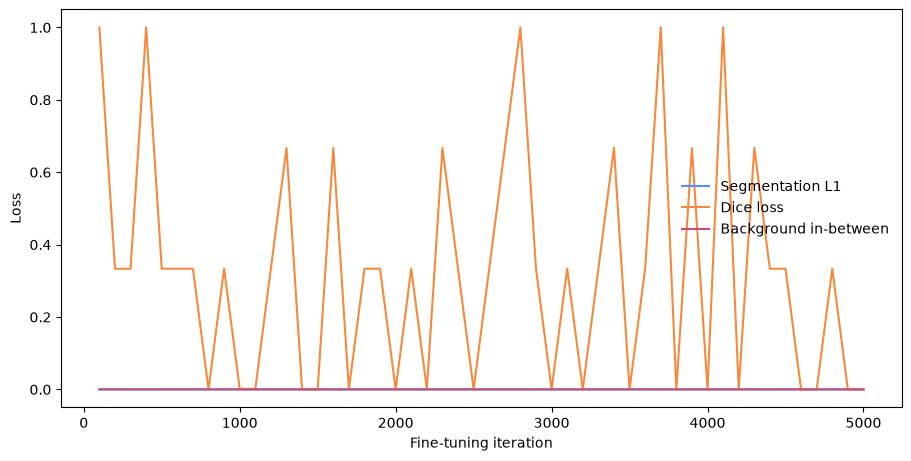

In [5]:
import matplotlib.pyplot as plt

history = pd.read_csv(
    MODEL_DIR / "history" / "seg_finetune_history.csv"
)

print("V12 segmentation-head fine-tuning history:")
display(history.tail())

figure, axis = plt.subplots(
    figsize=(9, 4.5),
    constrained_layout=True,
)

axis.plot(
    history["iteration"],
    history["seg_l1"],
    label="Segmentation L1",
)
axis.plot(
    history["iteration"],
    history["dice_loss"],
    label="Dice loss",
)
axis.plot(
    history["iteration"],
    history["bg_inter"],
    label="Background in-between",
)

axis.set_xlabel("Fine-tuning iteration")
axis.set_ylabel("Loss")
axis.legend(frameon=False)

EVAL_DIR.mkdir(parents=True, exist_ok=True)
figure.savefig(
    EVAL_DIR / "v12_finetune_losses.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()

# 5. Dense mask reconstruction

In [6]:
def render_source_for_slice(slice_index: int) -> tuple[int, int]:
    observed_array = np.asarray(
        observed_slices,
        dtype=int,
    )

    exact = np.flatnonzero(
        observed_array == slice_index
    )
    if len(exact):
        return int(exact[0]), 0

    right = int(
        np.searchsorted(
            observed_array,
            slice_index,
        )
    )
    left = right - 1

    gap = int(
        observed_array[right]
        - observed_array[left]
    )
    alpha = (
        slice_index
        - int(observed_array[left])
    ) / gap

    interp_index = int(
        round(alpha * SLICE_STRIDE)
    )

    return left, interp_index


shutil.rmtree(
    MODEL_DIR / "render_mask",
    ignore_errors=True,
)

print("Rendering fine-tuned segmentation head.")

render_command = [
    sys.executable,
    str(MEDGS_REPO / "render.py"),
    "--model_path", str(MODEL_DIR),
    "--iteration", str(FINETUNE_ITERATIONS),
    "--interp", str(SLICE_STRIDE),
    "--pipeline", "seg",
    "--chunks", str(RENDER_CHUNKS),
    "--poly_degree", str(POLY_DEGREE),
    "--camera", "mirror",
]

subprocess.run(
    render_command,
    cwd=MEDGS_REPO,
    check=True,
)

shutil.rmtree(
    DENSE_MASK_DIR,
    ignore_errors=True,
)
DENSE_MASK_DIR.mkdir(parents=True)

mapping_rows = []

for slice_index in evaluation_slices:
    frame_index, interp_index = render_source_for_slice(
        slice_index
    )
    source_name = (
        f"{frame_index:05d}_{interp_index}.png"
    )

    source_path = (
        MODEL_DIR
        / "render_mask"
        / source_name
    )
    assert source_path.is_file(), source_path

    target_path = (
        DENSE_MASK_DIR
        / f"{slice_index:04d}.png"
    )
    shutil.copy2(
        source_path,
        target_path,
    )

    mapping_rows.append(
        {
            "SliceIndex": slice_index,
            "Observed": slice_index in observed_set,
            "MedGSFrame": frame_index,
            "InterpIndex": interp_index,
        }
    )

render_mapping = pd.DataFrame(mapping_rows)
render_mapping.to_csv(
    V12_ROOT / "render_mapping.csv",
    index=False,
)

predicted_mask_scores = np.stack(
    [
        np.asarray(
            Image.open(
                DENSE_MASK_DIR / f"{i:04d}.png"
            ).convert("L"),
            dtype=np.uint8,
        )
        for i in evaluation_slices
    ]
)

predicted_mask = (
    predicted_mask_scores >= MASK_THRESHOLD
)

print("Dense masks reconstructed:", len(predicted_mask))

Rendering fine-tuned segmentation head.


/home/jovyan/shared/mtm_medgs_stack/repo/MedGS/render.py:168: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_state, loaded_iter = torch.load(ckpt_path, map_location="cu

Looking for config file in /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_local71_107_stride3_poly7_bginter_v12_seg_finetune/model/cfg_args
Config file found: /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_local71_107_stride3_poly7_bginter_v12_seg_finetune/model/cfg_args
Rendering /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_local71_107_stride3_poly7_bginter_v12_seg_finetune/model
Distance: 1.0 [02/09 12:17:17]
Loading trained model at iteration 5000 [02/09 12:17:17]
Creating Training Transforms [02/09 12:17:17]
Creating Test Transforms [02/09 12:17:17]
AAAAA radius 1.1 [02/09 12:17:17]
AAAAA translate [-0. -0. -0.] center [0. 0. 0.] [02/09 12:17:17]
Generating random point cloud (100000)... [02/09 12:17:17]
Loading Training Cameras [02/09 12:17:17]
Loading Test Cameras [02/09 12:17:18]
Loading checkpoint: /home/jovyan/shared/mtm_med

Rendering progress:   0%|          | 0/4 [00:00<?, ?it/s]

[render] chunk 2/4: views 4..7 [02/09 12:17:18]


...

[render] chunk 3/4: views 8..11 [02/09 12:17:18]


Rendering progress: 100%|██████████| 4/4 [00:00<00:00, 33.42it/s]


[render] chunk 4/4: views 12..12 [02/09 12:17:19]


Rendering progress: 100%|██████████| 1/1 [00:00<00:00, 32.27it/s]


Dense masks reconstructed: 37


# 6. 2D evaluation

In [7]:
metric_rows = []

for local_index, slice_index in enumerate(
    evaluation_slices
):
    gt_mask = reference_mask_eval[local_index]
    pred_mask = predicted_mask[local_index]

    metric_rows.append(
        {
            "SliceIndex": slice_index,
            "Observed": slice_index in observed_set,
            "TumorGT": bool(gt_mask.any()),
            "GTPixels": int(gt_mask.sum()),
            "PredictedPixels": int(pred_mask.sum()),
            "ScoreMax": int(
                predicted_mask_scores[
                    local_index
                ].max()
            ),
            "ScoreMean": float(
                predicted_mask_scores[
                    local_index
                ].mean()
            ),
            "Dice": binary_dice(
                pred_mask,
                gt_mask,
            ),
            "IoU": binary_iou(
                pred_mask,
                gt_mask,
            ),
        }
    )

per_slice = pd.DataFrame(metric_rows)

missing_frame = per_slice[
    ~per_slice["Observed"]
]
tumor_missing_frame = per_slice[
    per_slice["SliceIndex"].isin(
        tumor_missing_slices
    )
]
empty_missing_frame = missing_frame[
    ~missing_frame["TumorGT"]
]

summary_rows = []

for name, frame in [
    ("all", per_slice),
    (
        "observed",
        per_slice[per_slice["Observed"]],
    ),
    ("missing_all", missing_frame),
    ("tumor_missing", tumor_missing_frame),
    ("empty_missing", empty_missing_frame),
]:
    summary_rows.append(
        {
            "Split": name,
            "Slices": len(frame),
            "Dice": float(frame["Dice"].mean()),
            "IoU": float(frame["IoU"].mean()),
        }
    )

summary = pd.DataFrame(summary_rows)

EVAL_DIR.mkdir(parents=True, exist_ok=True)
per_slice.to_csv(
    EVAL_DIR / "per_slice.csv",
    index=False,
)
summary.to_csv(
    EVAL_DIR / "summary.csv",
    index=False,
)

print("V12 reconstruction metrics:")
display(summary)

print("V12 held-out tumor slices:")
display(
    per_slice[
        per_slice["SliceIndex"].isin(
            tumor_missing_slices
        )
    ][
        [
            "SliceIndex",
            "GTPixels",
            "PredictedPixels",
            "Dice",
            "IoU",
        ]
    ]
)

V12 reconstruction metrics:


,Split,Slices,Dice,IoU
0,all,37,0.767501,0.750225
1,observed,13,0.923077,0.923077
2,missing_all,24,0.683231,0.656597
3,tumor_missing,4,0.599385,0.439585
4,empty_missing,20,0.700000,0.700000


V12 held-out tumor slices:


,SliceIndex,GTPixels,PredictedPixels,Dice,IoU
16,87,581,177,0.467018,0.304647
17,88,583,380,0.764278,0.618487
19,90,422,318,0.675676,0.510204
20,91,385,145,0.490566,0.325000


In [8]:
thresholds = [
    50, 75, 100, 125,
    150, 175, 200, 225,
]

tumor_local_indices = [
    evaluation_slices.index(i)
    for i in tumor_missing_slices
]

empty_local_indices = [
    local_index
    for local_index, slice_index
    in enumerate(evaluation_slices)
    if slice_index not in tumor_slices
]

observed_empty_local_indices = [
    evaluation_slices.index(i)
    for i in observed_empty_slices
]

threshold_rows = []

for threshold in thresholds:
    mask_at_threshold = (
        predicted_mask_scores >= threshold
    )

    tumor_dice = np.mean(
        [
            binary_dice(
                mask_at_threshold[i],
                reference_mask_eval[i],
            )
            for i in tumor_local_indices
        ]
    )

    tumor_iou = np.mean(
        [
            binary_iou(
                mask_at_threshold[i],
                reference_mask_eval[i],
            )
            for i in tumor_local_indices
        ]
    )

    false_positive_pixels = int(
        mask_at_threshold[
            empty_local_indices
        ].sum()
    )

    positive_empty_slices = int(
        np.sum(
            mask_at_threshold[
                empty_local_indices
            ]
            .reshape(
                len(empty_local_indices),
                -1,
            )
            .any(axis=1)
        )
    )

    positive_observed_empty = int(
        np.sum(
            mask_at_threshold[
                observed_empty_local_indices
            ]
            .reshape(
                len(
                    observed_empty_local_indices
                ),
                -1,
            )
            .any(axis=1)
        )
    )

    threshold_rows.append(
        {
            "Threshold": threshold,
            "TumorMissingDice": float(
                tumor_dice
            ),
            "TumorMissingIoU": float(
                tumor_iou
            ),
            "FalsePositivePixelsOutsideTumor": (
                false_positive_pixels
            ),
            "PositiveSlicesOutsideTumor": (
                positive_empty_slices
            ),
            "PositiveObservedEmptySlices": (
                positive_observed_empty
            ),
        }
    )

threshold_results = pd.DataFrame(
    threshold_rows
)

threshold_results.to_csv(
    EVAL_DIR / "threshold_sweep.csv",
    index=False,
)

print("V12 threshold sensitivity:")
display(threshold_results)

V12 threshold sensitivity:


,Threshold,TumorMissingDice,TumorMissingIoU,FalsePositivePixelsOutsideTumor,PositiveSlicesOutsideTumor,PositiveObservedEmptySlices
0,50,0.693987,0.552561,464,9,2
1,75,0.674533,0.529110,416,7,1
2,100,0.651474,0.500455,379,7,1
3,125,0.628698,0.473186,349,7,1
4,150,0.599385,0.439585,312,7,1
5,175,0.559770,0.395649,275,7,1
6,200,0.511715,0.347713,241,6,1
7,225,0.471755,0.310713,211,6,1


# 7. Mesh reconstruction

In [9]:
mesh_input_root = V12_ROOT / "mesh_input"
mesh_case_dir = (
    mesh_input_root
    / "case"
    / "render"
)
mesh_output_dir = V12_ROOT / "mesh"

predicted_mesh = None
mesh_metrics_serializable = None

if (
    predicted_mask_scores.max()
    == predicted_mask_scores.min()
):
    print("Mesh skipped: rendered masks are constant.")
else:
    shutil.rmtree(
        mesh_input_root,
        ignore_errors=True,
    )
    shutil.rmtree(
        mesh_output_dir,
        ignore_errors=True,
    )

    mesh_case_dir.mkdir(parents=True)
    mesh_output_dir.mkdir(parents=True)

    for local_index, slice_index in enumerate(
        evaluation_slices
    ):
        shutil.copy2(
            DENSE_MASK_DIR / f"{slice_index:04d}.png",
            mesh_case_dir / f"{local_index:05d}_0.png",
        )

    print("Building V12 tumor mesh.")

    mesh_command = [
        sys.executable,
        str(MEDGS_REPO / "slices_to_ply.py"),
        "--input", str(mesh_input_root),
        "--output", str(mesh_output_dir),
        "--thresh", str(MESH_THRESHOLD),
        "--inter", "1",
    ]

    subprocess.run(
        mesh_command,
        cwd=MEDGS_REPO,
        check=True,
    )

    import open3d as o3d

    medgs_ply = mesh_output_dir / "case.ply"
    o3d_mesh = o3d.io.read_triangle_mesh(
        str(medgs_ply)
    )

    vertices_zyx = np.asarray(
        o3d_mesh.vertices,
        dtype=np.float64,
    ).copy()

    faces = np.asarray(
        o3d_mesh.triangles,
        dtype=np.int64,
    )

    vertices_zyx[:, 0] += RANGE_START

    vertices_xyz = (
        geometry.index_zyx_to_patient_xyz(
            vertices_zyx
        )
    )

    predicted_mesh = TriangleMesh(
        vertices_zyx=vertices_zyx,
        vertices_xyz=vertices_xyz,
        faces=faces,
    )

    write_ply(
        mesh_output_dir
        / "case_patient_coordinates.ply",
        vertices_xyz,
        faces,
    )

    mesh_metrics = (
        evaluate_mesh_against_reference(
            predicted_mesh,
            reference_mesh,
            reference_mask,
            geometry,
        )
    )
    mesh_metrics.pop("CandidateMask")

    mesh_metrics_serializable = {
        key: (
            value.item()
            if isinstance(value, np.generic)
            else value
        )
        for key, value in mesh_metrics.items()
    }

    (
        EVAL_DIR / "mesh_metrics.json"
    ).write_text(
        json.dumps(
            mesh_metrics_serializable,
            indent=2,
            sort_keys=True,
        ),
        encoding="utf-8",
    )

    print("V12 mesh reconstruction metrics:")
    display(
        pd.DataFrame.from_dict(
            mesh_metrics_serializable,
            orient="index",
            columns=["Value"],
        )
    )

Building V12 tumor mesh.
caseing PLY: [=======================================>] 97%
Volume shape (slices, height, width): (37, 512, 512)
Saved mesh to /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_local71_107_stride3_poly7_bginter_v12_seg_finetune/mesh/case.ply
Writing PLY: [========================================] 100%
Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
V12 mesh reconstruction metrics:


,Value
Dice,0.460707
IoU,0.299298
MeanSurfaceDistanceMm,5.346366
HD95Mm,18.656481
CentroidErrorMm,0.89171
VolumeMm3,24148.29584
ReferenceVolumeMm3,8020.063232
VolumeErrorMm3,16128.232608
VolumeErrorPercent,201.098572
SurfaceAreaMm2,4825.495215


# 8. V11-B vs V12

In [10]:
v11_summary = pd.read_csv(
    V11_B_RUN / "evaluation" / "summary.csv"
)
v11_thresholds = pd.read_csv(
    V11_B_RUN
    / "evaluation"
    / "threshold_sweep.csv"
)
v11_diagnostics = pd.read_csv(
    V11_B_RUN
    / "evaluation"
    / "mask_diagnostics.csv"
)

with open(
    V11_B_RUN
    / "evaluation"
    / "mesh_metrics.json",
    encoding="utf-8",
) as fp:
    v11_mesh = json.load(fp)

v11_tumor = v11_summary.loc[
    v11_summary["Split"] == "tumor_missing"
].iloc[0]

v11_threshold = v11_thresholds.loc[
    v11_thresholds["Threshold"]
    == MASK_THRESHOLD
].iloc[0]

v12_tumor = summary.loc[
    summary["Split"] == "tumor_missing"
].iloc[0]

v12_threshold = threshold_results.loc[
    threshold_results["Threshold"]
    == MASK_THRESHOLD
].iloc[0]

comparison = pd.DataFrame(
    [
        {
            "Method": "V11-B joint",
            "TumorMissingDice": float(
                v11_tumor["Dice"]
            ),
            "TumorMissingIoU": float(
                v11_tumor["IoU"]
            ),
            "FalsePositivePixelsOutsideTumor": int(
                v11_threshold[
                    "FalsePositivePixelsOutsideTumor"
                ]
            ),
            "PositiveSlicesOutsideTumor": int(
                v11_threshold[
                    "PositiveSlicesOutsideTumor"
                ]
            ),
            "PositiveObservedEmptySlices": int(
                v11_threshold[
                    "PositiveObservedEmptySlices"
                ]
            ),
            "MeshDice": float(
                v11_mesh["Dice"]
            ),
            "HD95Mm": float(
                v11_mesh["HD95Mm"]
            ),
            "VolumeErrorPercent": float(
                v11_mesh["VolumeErrorPercent"]
            ),
        },
        {
            "Method": "V12 seg-head fine-tune",
            "TumorMissingDice": float(
                v12_tumor["Dice"]
            ),
            "TumorMissingIoU": float(
                v12_tumor["IoU"]
            ),
            "FalsePositivePixelsOutsideTumor": int(
                v12_threshold[
                    "FalsePositivePixelsOutsideTumor"
                ]
            ),
            "PositiveSlicesOutsideTumor": int(
                v12_threshold[
                    "PositiveSlicesOutsideTumor"
                ]
            ),
            "PositiveObservedEmptySlices": int(
                v12_threshold[
                    "PositiveObservedEmptySlices"
                ]
            ),
            "MeshDice": (
                float(
                    mesh_metrics_serializable[
                        "Dice"
                    ]
                )
                if mesh_metrics_serializable
                is not None
                else np.nan
            ),
            "HD95Mm": (
                float(
                    mesh_metrics_serializable[
                        "HD95Mm"
                    ]
                )
                if mesh_metrics_serializable
                is not None
                else np.nan
            ),
            "VolumeErrorPercent": (
                float(
                    mesh_metrics_serializable[
                        "VolumeErrorPercent"
                    ]
                )
                if mesh_metrics_serializable
                is not None
                else np.nan
            ),
        },
    ]
)

comparison.to_csv(
    V12_ROOT / "v11b_vs_v12.csv",
    index=False,
)

print("V11-B versus V12:")
display(comparison)

delta_dice = (
    comparison.loc[
        comparison["Method"]
        == "V12 seg-head fine-tune",
        "TumorMissingDice",
    ].iloc[0]
    - comparison.loc[
        comparison["Method"]
        == "V11-B joint",
        "TumorMissingDice",
    ].iloc[0]
)

print(
    "Change in held-out tumor Dice:",
    f"{delta_dice:+.4f}",
)

V11-B versus V12:


,Method,TumorMissingDice,TumorMissingIoU,FalsePositivePixelsOutsideTumor,PositiveSlicesOutsideTumor,PositiveObservedEmptySlices,MeshDice,HD95Mm,VolumeErrorPercent
0,V11-B joint,0.625241,0.469539,371,8,1,0.451657,18.755978,215.079278
1,V12 seg-head fine-tune,0.599385,0.439585,312,7,1,0.460707,18.656481,201.098572


Change in held-out tumor Dice: -0.0259


GT foreground area before and after fine-tuning:


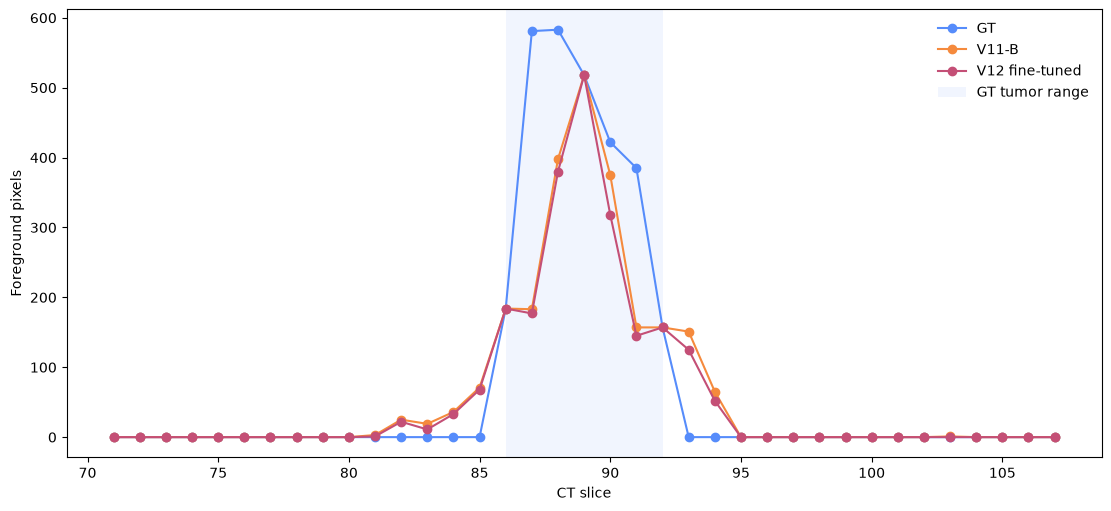

In [11]:
import matplotlib.pyplot as plt

print("GT foreground area before and after fine-tuning:")

figure, axis = plt.subplots(
    figsize=(11, 5),
    constrained_layout=True,
)

axis.plot(
    per_slice["SliceIndex"],
    per_slice["GTPixels"],
    marker="o",
    label="GT",
)

axis.plot(
    v11_diagnostics["SliceIndex"],
    v11_diagnostics["PredictedPixels"],
    marker="o",
    label="V11-B",
)

axis.plot(
    per_slice["SliceIndex"],
    per_slice["PredictedPixels"],
    marker="o",
    label="V12 fine-tuned",
)

axis.axvspan(
    TUMOR_START,
    TUMOR_END,
    alpha=0.08,
    label="GT tumor range",
)

axis.set_xlabel("CT slice")
axis.set_ylabel("Foreground pixels")
axis.legend(frameon=False)

figure.savefig(
    EVAL_DIR / "v11b_vs_v12_foreground.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()

# 9. Visual inspection

In [12]:
print(
    "V12 masks on the unchanged V11-B CT reconstruction:"
)

show_sparse_joint_slice_browser(
    ground_truth_ct,
    v11_b_predicted_ct,
    reference_mask_eval,
    predicted_mask,
    observed_slices,
    slice_start=RANGE_START,
)

if predicted_mesh is not None:
    print("Reference and V12 reconstructed tumor meshes.")
    show_sparse_joint_anatomy_3d(
        PHASE_DIR,
        predicted_mesh,
    )

V12 masks on the unchanged V11-B CT reconstruction:


Reference and V12 reconstructed tumor meshes.


# 10. Decision

Use the V11-B vs V12 table as the decision point.

If segmentation-head fine-tuning gives a clear improvement in held-out tumor Dice and/or spatial extent without damaging the mesh metrics, carry this stage into the final full-phase run. Otherwise keep V11-B as the final MedGS configuration.

The full-phase SDF baseline is intentionally outside this notebook.